PREPROCESSING 1D CNN

In [1]:
import os, pyedflib
import numpy as np
import scipy.signal as signal
import pywt
from tqdm import tqdm

EDF_DIR = "/Users/faizhenri/Downloads/object_detection_sleep/EDF_XML"
OUT_DIR = "/Users/faizhenri/Downloads/object_detection_sleep/preprocessed_ecg"
os.makedirs(OUT_DIR, exist_ok=True)

def read_ecg_from_edf(path):
    f = pyedflib.EdfReader(path)
    n = f.signals_in_file
    labels = [f.getLabel(i).lower() for i in range(n)]
    
    # Cari channel ECG
    ch_idx = next((i for i, label in enumerate(labels)
                   if "ecg" in label or "ekg" in label), 0)
    
    sig = f.readSignal(ch_idx)
    fs = int(f.getSampleFrequency(ch_idx))
    f._close()
    return sig, fs

def wavelet_denoise(ecg, wavelet="bior3.1", level=3):
    coeffs = pywt.wavedec(ecg, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(ecg)))
    coeffs[1:] = [pywt.threshold(c, value=uthresh, mode="soft") for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)

def bandpass_filter(ecg, fs, lowcut=0.5, highcut=40):
    nyq = 0.5 * fs
    b, a = signal.butter(4, [lowcut/nyq, highcut/nyq], btype='band')
    return signal.filtfilt(b, a, ecg)

def normalize_zscore(ecg):
    return (ecg - np.mean(ecg)) / (np.std(ecg) + 1e-8)

for fname in tqdm(sorted(os.listdir(EDF_DIR))):
    if not fname.endswith(".edf"): 
        continue
    subject = os.path.splitext(fname)[0]
    path = os.path.join(EDF_DIR, fname)
    
    ecg, fs = read_ecg_from_edf(path)
    ecg = wavelet_denoise(ecg)
    ecg = bandpass_filter(ecg, fs)
    ecg = normalize_zscore(ecg)
    
    np.save(os.path.join(OUT_DIR, f"{subject}.npy"), ecg.astype(np.float32))
    print(f"[✓] {subject} processed, len={len(ecg)/fs/3600:.2f} hours, fs={fs} Hz")


  5%|▍         | 5/104 [00:00<00:09, 10.78it/s]

[✓] s1 processed, len=6.66 hours, fs=200 Hz


  7%|▋         | 7/104 [00:00<00:13,  6.98it/s]

[✓] s10 processed, len=6.60 hours, fs=200 Hz


  8%|▊         | 8/104 [00:01<00:19,  4.92it/s]

...

[✓] s7 processed, len=6.83 hours, fs=200 Hz


 97%|█████████▋| 101/104 [00:21<00:00,  4.97it/s]

[✓] s8 processed, len=6.80 hours, fs=200 Hz


100%|██████████| 104/104 [00:21<00:00,  4.76it/s]

[✓] s9 processed, len=6.72 hours, fs=200 Hz


In [ ]:
import numpy as np, os
from tqdm import tqdm

SRC = "preprocessed_ecg"
OUT = "segments"
os.makedirs(OUT, exist_ok=True)

segment_duration = 10  # detik
stride = 5             # overlap 50%
fs = 200               # ubah sesuai EDF aslinya

for fname in tqdm(sorted(os.listdir(SRC))):
    if not fname.endswith(".npy"): continue
    subject = fname.replace(".npy", "")
    ecg = np.load(os.path.join(SRC, fname))
    total_samples = len(ecg)
    seg_len = int(segment_duration * fs)
    step = int(stride * fs)
    seg_idx = 0
    
    for start in range(0, total_samples - seg_len, step):
        end = start + seg_len
        seg = ecg[start:end]
        out_name = f"{subject}_{seg_idx:04d}.npy"
        np.save(os.path.join(OUT, out_name), seg)
        seg_idx += 1


In [7]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import pyedflib
import pandas as pd
from tqdm import tqdm

EDF_DIR = "/Users/faizhenri/Downloads/object_detection_sleep/EDF_XML"
OUT_CSV = "segment_labels.csv"

SEG_DUR = 135   # detik
STRIDE = 15     # detik

def read_ecg_info(edf_path):
    f = pyedflib.EdfReader(edf_path)
    fs = int(f.getSampleFrequency(0))
    total_sec = f.getFileDuration()
    f._close()
    return fs, total_sec

def parse_xml_events(xml_path):
    import xml.etree.ElementTree as ET
    import numpy as np

    events = []
    tree = ET.parse(xml_path)
    root = tree.getroot()

    for ev in root.findall(".//ScoredEvent"):
        name_tag = ev.find("Name")
        start_tag = ev.find("Start")
        dur_tag   = ev.find("Duration")

        if name_tag is None or start_tag is None or dur_tag is None:
            continue

        name = name_tag.text.strip().lower()
        # we only keep apnea or hypopnea events
        if any(k in name for k in ["apnea", "hypopnea"]):
            try:
                start = float(start_tag.text)
                dur = float(dur_tag.text)
                if dur > 0:
                    events.append((start, start + dur))
            except ValueError:
                continue

    return np.array(events)


def overlap(seg_start, seg_end, events):
    if len(events) == 0:
        return 0
    for (s, e) in events:
        if (s < seg_end) and (e > seg_start):  # ada irisan
            # hitung lamanya irisan
            olap = min(seg_end, e) - max(seg_start, s)
            if olap >= 5:   # minimal 5 detik overlap
                return 1
    return 0

records = []

for fname in tqdm(sorted(os.listdir(EDF_DIR))):
    if not fname.endswith(".edf"): 
        continue
    subject = os.path.splitext(fname)[0]
    edf_path = os.path.join(EDF_DIR, fname)
    xml_path = os.path.join(EDF_DIR, subject + ".xml")
    if not os.path.exists(xml_path):
        print(f"[!] No XML for {subject}, skipping...")
        continue

    fs, total_sec = read_ecg_info(edf_path)
    events = parse_xml_events(xml_path)

    seg_starts = np.arange(0, total_sec - SEG_DUR, STRIDE)
    for i, start in enumerate(seg_starts):
        end = start + SEG_DUR
        label = overlap(start, end, events)
        records.append([subject, i, start, end, label])

df = pd.DataFrame(records, columns=["subject", "segment_idx", "start_sec", "end_sec", "label"])
df.to_csv(OUT_CSV, index=False)
print(f"[✓] Saved labels to {OUT_CSV}")


100%|██████████| 104/104 [00:02<00:00, 35.65it/s]

[✓] Saved labels to segment_labels.csv


In [8]:
import os
import numpy as np
import pandas as pd
import pyedflib
import pywt
import scipy.signal as signal
from tqdm import tqdm

EDF_DIR = "/Users/faizhenri/Downloads/object_detection_sleep/EDF_XML"
LABEL_CSV = "segment_labels.csv"
OUT_DIR = "segmented_npy"
os.makedirs(OUT_DIR, exist_ok=True)

def read_ecg_from_edf(path):
    f = pyedflib.EdfReader(path)
    n = f.signals_in_file
    labels = [f.getLabel(i).lower() for i in range(n)]
    ch_idx = next((i for i, label in enumerate(labels)
                   if "ecg" in label or "ekg" in label), 0)
    sig = f.readSignal(ch_idx)
    fs = int(f.getSampleFrequency(ch_idx))
    f._close()
    return sig, fs

def wavelet_denoise(sig, wavelet="bior3.1", level=3):
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(sig)))
    coeffs[1:] = [pywt.threshold(c, value=uthresh, mode="soft") for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)

def bandpass_filter(sig, fs, lowcut=0.5, highcut=40):
    nyq = 0.5 * fs
    b, a = signal.butter(4, [lowcut/nyq, highcut/nyq], btype='band')
    return signal.filtfilt(b, a, sig)

def normalize(sig):
    return (sig - np.mean(sig)) / (np.std(sig) + 1e-8)

# === Main process ===
df = pd.read_csv(LABEL_CSV)
subjects = df["subject"].unique()

for subj in tqdm(subjects):
    edf_path = os.path.join(EDF_DIR, f"{subj}.edf")
    if not os.path.exists(edf_path):
        print(f"[!] EDF for {subj} not found, skip.")
        continue

    ecg, fs = read_ecg_from_edf(edf_path)
    ecg = wavelet_denoise(ecg)
    ecg = bandpass_filter(ecg, fs)
    ecg = normalize(ecg)

    df_subj = df[df["subject"] == subj]
    for _, row in df_subj.iterrows():
        idx = int(row["segment_idx"])
        start_samp = int(row["start_sec"] * fs)
        end_samp   = int(row["end_sec"] * fs)
        label = int(row["label"])

        segment = ecg[start_samp:end_samp]
        if len(segment) == 0:
            continue

        out_name = f"{subj}_{idx:04d}_label{label}.npy"
        np.save(os.path.join(OUT_DIR, out_name), segment.astype(np.float32))

print(f"[✓] Done. Segments saved in '{OUT_DIR}'")


100%|██████████| 50/50 [00:39<00:00,  1.26it/s]

[✓] Done. Segments saved in 'segmented_npy'


In [12]:
import numpy as np, glob
x = np.load(sorted(glob.glob("segmented_npy/*.npy"))[0])
print(x.shape, len(x))

(27000,) 27000


In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
import glob, os, numpy as np

class ECGSegmentDataset(Dataset):
    def __init__(self, seg_dir):
        self.paths = sorted(glob.glob(os.path.join(seg_dir, "*.npy")))
        self.labels = [int(os.path.basename(p).split("label")[-1].split(".npy")[0])
                       for p in self.paths]
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        x = np.load(self.paths[i])
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

dataset = ECGSegmentDataset("segmented_npy")
loader  = DataLoader(dataset, batch_size=32, shuffle=True)
print(len(dataset), "segments loaded")


80493 segments loaded


In [18]:
import torch.nn as nn, math

class SincConv1d(nn.Module):
    def __init__(self, out_channels, kernel_size, sample_rate=200):
        super().__init__()
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.sample_rate  = sample_rate
        self.min_freq, self.max_freq = 0.5, sample_rate/2 - 1
        low_hz  = np.linspace(self.min_freq, 30, out_channels)
        high_hz = low_hz + 5
        self.low_hz_ = nn.Parameter(torch.Tensor(low_hz))
        self.band_hz_ = nn.Parameter(torch.Tensor(high_hz - low_hz))
        n = torch.arange(-(kernel_size//2), (kernel_size//2)+ 1)
        self.register_buffer("n", n)

    def forward(self, x):
        low  = self.min_freq + torch.abs(self.low_hz_)
        high = torch.clamp(low + torch.abs(self.band_hz_), self.min_freq, self.max_freq)
        band = (high - low)[:, None]
        f_t_low  = 2*math.pi*low[:,None]*self.n/self.sample_rate
        f_t_high = 2*math.pi*high[:,None]*self.n/self.sample_rate
        filters = (torch.sin(f_t_high) - torch.sin(f_t_low)) / (self.n/self.sample_rate + 1e-8)
        filters = filters / (2*band)
        filters = filters * torch.hamming_window(self.kernel_size).to(x.device)
        filters = filters.unsqueeze(1)
        return torch.conv1d(x, filters, stride=1, padding=self.kernel_size//2)

class SincNetDemo(nn.Module):
    def __init__(self, sample_rate=200):
        super().__init__()
        self.sinc = SincConv1d(16, 251, sample_rate)
        self.pool = nn.MaxPool1d(4)
        self.conv = nn.Conv1d(16, 32, 5)
        self.gap  = nn.AdaptiveAvgPool1d(1)  # <— global pooling
        self.fc   = nn.Linear(32, 2)          # hanya 32 fitur masuk FC

    def forward(self, x):
        x = torch.relu(self.pool(self.sinc(x)))
        x = torch.relu(self.conv(x))
        x = self.gap(x)             # [B,32,1]
        x = x.view(x.size(0), -1)   # [B,32]
        return self.fc(x)


In [19]:
model = SincNetDemo(sample_rate=200)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    total_loss = 0
    for x, y in loader:
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: Loss={total_loss/len(loader):.4f}")


Epoch 1: Loss=0.6284
Epoch 2: Loss=0.5802
Epoch 3: Loss=0.5516
Epoch 4: Loss=0.5363
Epoch 5: Loss=0.5227


In [22]:
model = SincNetDemo(sample_rate=200)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    total_loss = 0
    for x, y in loader:
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: Loss={total_loss/len(loader):.4f}")

Epoch 1: Loss=0.6614
Epoch 2: Loss=0.6381
Epoch 3: Loss=0.6276
Epoch 4: Loss=0.6202
Epoch 5: Loss=0.6138


In [20]:
low  = model.sinc.min_freq + torch.abs(model.sinc.low_hz_).detach().cpu().numpy()
high = low + torch.abs(model.sinc.band_hz_).detach().cpu().numpy()
for i,(l,h) in enumerate(zip(low,high)):
    print(f"Filter {i+1}: {l:.2f}–{h:.2f} Hz")


Filter 1: 0.91–5.92 Hz
Filter 2: 3.20–7.84 Hz
Filter 3: 4.69–9.48 Hz
Filter 4: 6.64–11.79 Hz
Filter 5: 8.59–13.39 Hz
Filter 6: 10.60–15.45 Hz
Filter 7: 12.15–17.29 Hz
Filter 8: 14.55–19.47 Hz
Filter 9: 16.33–21.11 Hz
Filter 10: 18.91–24.04 Hz
Filter 11: 21.03–26.19 Hz
Filter 12: 22.32–27.49 Hz
Filter 13: 24.08–29.19 Hz
Filter 14: 26.64–31.83 Hz
Filter 15: 28.67–33.82 Hz
Filter 16: 30.66–35.48 Hz


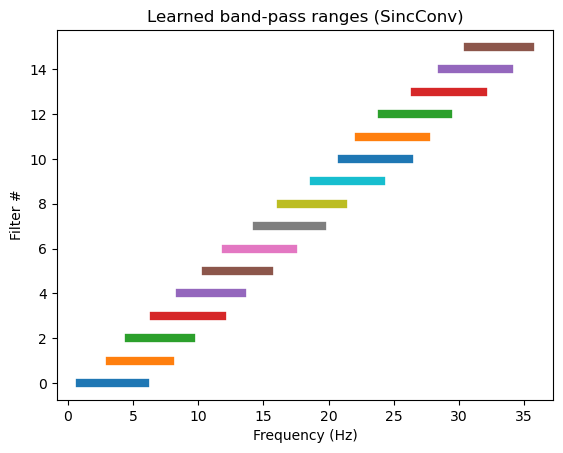

In [21]:
import matplotlib.pyplot as plt
for i in range(len(low)):
    plt.plot([low[i], high[i]], [i,i], lw=6)
plt.xlabel("Frequency (Hz)"); plt.ylabel("Filter #")
plt.title("Learned band-pass ranges (SincConv)")
plt.show()


In [25]:
# Check real sampling rate from EDF files
import pyedflib
import os

EDF_DIR = "/Users/faizhenri/Downloads/object_detection_sleep/EDF_XML"

# Check first few EDF files
count = 0
for fname in sorted(os.listdir(EDF_DIR)):
    if not fname.lower().endswith(".edf"):  # handle both .edf and .EDF
        continue
    
    if count >= 3:  # Check first 3 files
        break
    count += 1
    
    edf_path = os.path.join(EDF_DIR, fname)
    f = pyedflib.EdfReader(edf_path)
    
    print(f"\n{'='*60}")
    print(f"File: {fname}")
    print(f"{'='*60}")
    print(f"Number of signals: {f.signals_in_file}")
    print(f"Recording duration: {f.getFileDuration():.2f} seconds ({f.getFileDuration()/3600:.2f} hours)")
    print(f"\nChannel details:")
    
    # Check all channels
    for i in range(f.signals_in_file):
        label = f.getLabel(i)
        fs = f.getSampleFrequency(i)
        n_samples = f.getNSamples()[i]
        print(f"  Channel {i}: {label:20s} | Sampling rate: {fs:6.1f} Hz | Samples: {n_samples}")
    
    f._close()

print("\n" + "="*60)
print("Summary: Look for ECG/EKG channel above to see its sampling rate")


File: s1.edf
Number of signals: 21
Recording duration: 23993.00 seconds (6.66 hours)

Channel details:
  Channel 0: C3-M2                | Sampling rate:  200.0 Hz | Samples: 4798600
  Channel 1: C4-M1                | Sampling rate:  200.0 Hz | Samples: 4798600
  Channel 2: F3-M2                | Sampling rate:  200.0 Hz | Samples: 4798600
  Channel 3: F4-M1                | Sampling rate:  200.0 Hz | Samples: 4798600
  Channel 4: O1-M2                | Sampling rate:  200.0 Hz | Samples: 4798600
  Channel 5: O2-M1                | Sampling rate:  200.0 Hz | Samples: 4798600
  Channel 6: E1-M2                | Sampling rate:  200.0 Hz | Samples: 4798600
  Channel 7: E2-M2                | Sampling rate:  200.0 Hz | Samples: 4798600
  Channel 8: EMG-R                | Sampling rate:  200.0 Hz | Samples: 4798600
  Channel 9: ECG                  | Sampling rate:  200.0 Hz | Samples: 4798600
  Channel 10: Sound                | Sampling rate:   25.0 Hz | Samples: 599825
  Channel 11: NP

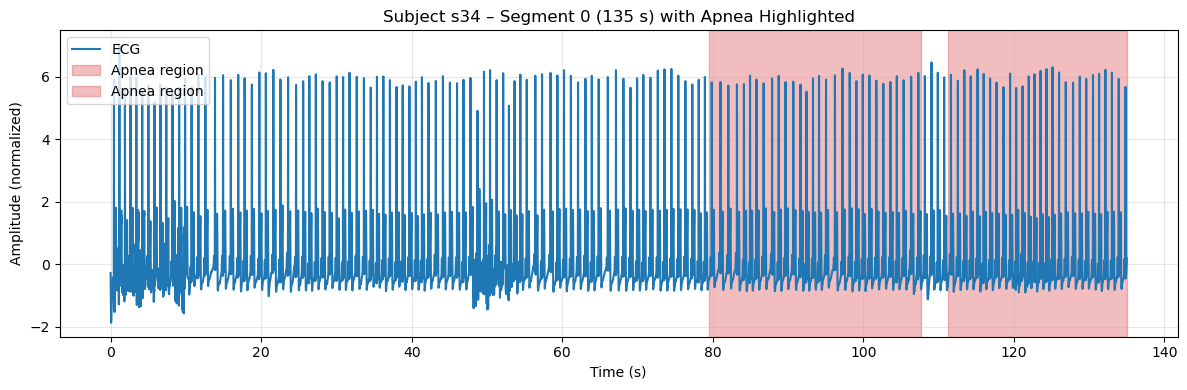

In [28]:
x = np.load("segmented_npy/s34_0000_label1.npy")
fs = 200
t = np.arange(len(x)) / fs
# convert global apnea times to segment-relative
apnea_local = [(max(s,0)-0, min(e,135)-0) for s,e in events if e>0 and s<135]

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(t, x, color='tab:blue', label='ECG')
for s_rel, e_rel in apnea_local:
    plt.axvspan(s_rel, e_rel, color='tab:red', alpha=0.3, label='Apnea region')
plt.title("Subject s34 – Segment 0 (135 s) with Apnea Highlighted")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (normalized)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
